In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data


In [ ]:
df = pd.read_csv("CleanedData.csv")
df = df.drop(df.loc[:, "IL_1to3":"BU_1to3"].columns, axis=1) # drop the "subsections of jaw" columns
df.drop(columns=['Dateofbirth'], inplace=True)

In [ ]:
# Make small dataset that store cols of DMEAN as well as PatientID
dmean_cols = ["PatientID"] + df.loc[:, "DmeanGyCU1F":"DmeanGyCL8F"].columns.tolist()
dmean_df = df[dmean_cols]  
dmean_cols = df.loc[:, "DmeanGyCU1F":"DmeanGyCL8F"].columns.tolist()

# new cols that count how many necessary and unnecessary extractions per patient
df["Necessary_dmean"] = (df[dmean_cols] == 1).sum(axis=1)
df["Unnecessary_dmean"] = (df[dmean_cols] == 0).sum(axis=1)

df.head()

In [ ]:
# Make small dataset that store cols of DMax as well as PatientID
dmax_cols = ["PatientID"] + df.loc[:, "DmaxGyCU1F":"DmaxGyCL8F"].columns.tolist()
dmean_df = df[dmax_cols]  
dmax_cols = df.loc[:, "DmaxGyCU1F":"DmaxGyCL8F"].columns.tolist()

# new cols that count how many necessary and unnecessary extractions per patient
df["Necessary_dmax"] = (df[dmax_cols] == 1).sum(axis=1)
df["Unnecessary_dmax"] = (df[dmax_cols] == 0).sum(axis=1)

df.head()

In [ ]:
filtered_columns = [col for col in df.columns if ((
    "dmax" not in col.lower() and "dmean" not in col.lower()
) or col.lower() in ["necessary_dmean", "unnecessary_dmean", "necessary_dmax", "unnecessary_dmax"])]
print(filtered_columns)

df = df[filtered_columns]

# Analysis of Numerical values in original dataset

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if ".1" not in col and ".2" not in col and "PatientID" not in col]

continuous_vars = [col for col in numeric_cols if df[col].nunique() > 10]

print("Identified continuous variables:", continuous_vars)

print("\nDescriptive statistics for continuous variables (including NA count):")
desc = df[continuous_vars].describe().T
desc['NA'] = df[continuous_vars].isna().sum()
print(desc)

# Analysis of categorical values in original dataset

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("Identified categorical variables:", categorical_cols)

for col in categorical_cols:
    freq = df[col].value_counts(dropna=False)  # include NaNs
    prop = df[col].value_counts(normalize=True, dropna=False)

    print(f"\nFrequency counts for {col} (including NA):")
    print(freq)


# 2. Creating 2 seperate datasets for prediction models

In [10]:
df = pd.read_csv("/Users/ashademeij/Downloads/Thesis/TIP_Maastro/data/CleanedData.csv")
df = df.drop(df.loc[:, "IL_1to3":"BU_1to3"].columns, axis=1) # drop the "subsections of jaw" columns
df.drop(columns=['Dateofbirth'], inplace=True)

# Dmean dataset first

In [ ]:
predictor_cols = [
    "TumorLaterality", "TumorLocation", "TNM_T", "TNM_N",
    "TNM_Stage", "TotalDose", "Typetumor_cat", "Tumor_site",
    "Stage", "Systemic_therapy", "StageItmIV"
]

In [ ]:
columns_first = [f'DmeanGy{i}' for i in range(11, 19)] + [f'DmeanGy{i}' for i in range(21, 29)] + [f'DmeanGy{i}' for i in range(31, 39)] + [f'DmeanGy{i}' for i in range(41, 49)]

g1 = [f'DmeanGyCU{i}F' for i in range(1, 9)]   
g2 = [f'DmeanGyIU{i}F' for i in range(1, 9)]   
g3 = [f'DmeanGyIL{i}F' for i in range(1, 9)]   
g4 = [f'DmeanGyCL{i}F' for i in range(1, 9)]   


rename_dict = {}

# Group 1: Map DmeanGyCU{i}F to DmeanB{10+i} (i from 1 to 8 → DmeanB11 to DmeanB18)
for col in g1:
    i = int(col.replace("DmeanGyCU", "").replace("F", ""))
    rename_dict[col] = f"DmeanB{10 + i}"

for col in g2:
    i = int(col.replace("DmeanGyIU", "").replace("F", ""))
    rename_dict[col] = f"DmeanB{20 + i}"

for col in g3:
    i = int(col.replace("DmeanGyIL", "").replace("F", ""))
    rename_dict[col] = f"DmeanB{30 + i}"

for col in g4:
    i = int(col.replace("DmeanGyCL", "").replace("F", ""))
    rename_dict[col] = f"DmeanB{40 + i}"

columns_second = g1 + g2 + g3 + g4
selected_columns = ["PatientID"] + columns_first + columns_second

dmean_df = df[selected_columns].copy()
dmean_df.rename(columns=rename_dict, inplace=True)

dmean_df.head()

In [ ]:
melted_df = pd.wide_to_long(
    dmean_df,
    stubnames=["DmeanGy", "DmeanB"],  
    i="PatientID",                    
    j="ToothType",                    
    suffix=r"\d+",                    
    sep=""                           
).reset_index()

melted_df.rename(columns={"DmeanGy": "DoseMean", "DmeanB": "ExtractionFlag"}, inplace=True)

print("NaN in DoseMean:", melted_df["DoseMean"].isna().sum())
print("NaN in ExtractionFlag:", melted_df["ExtractionFlag"].isna().sum())

melted_df.dropna(subset=["ExtractionFlag"], inplace=True)

valid_tooth_types = (
    list(range(11, 19)) +
    list(range(21, 29)) +
    list(range(31, 39)) +
    list(range(41, 49))
)
melted_df = melted_df[melted_df["ToothType"].isin(valid_tooth_types)]
melted_df = melted_df[["PatientID", "ToothType", "ExtractionFlag"]]

melted_df.head()


In [14]:
relevant_cols = [
    "PatientID", "TumorLaterality", "TumorLocation", "TNM_T", "TNM_N",
    "TNM_Stage", "TotalDose", "Typetumor_cat", "Tumor_site",
    "Stage", "Systemic_therapy", "StageItmIV"
]

features = df[relevant_cols]

In [ ]:
dmean_dff = melted_df.copy()
dmean_dff = dmean_dff.merge(features, on="PatientID", how="left")
dmean_dff = dmean_dff[~((dmean_dff['StageItmIV'] == 99.0) | (dmean_dff['Stage'] == 99.0))]
print(dmean_dff.shape)
dmean_dff.head()

In [ ]:
dmean_dff.to_csv("dmean_df.csv", index=False)

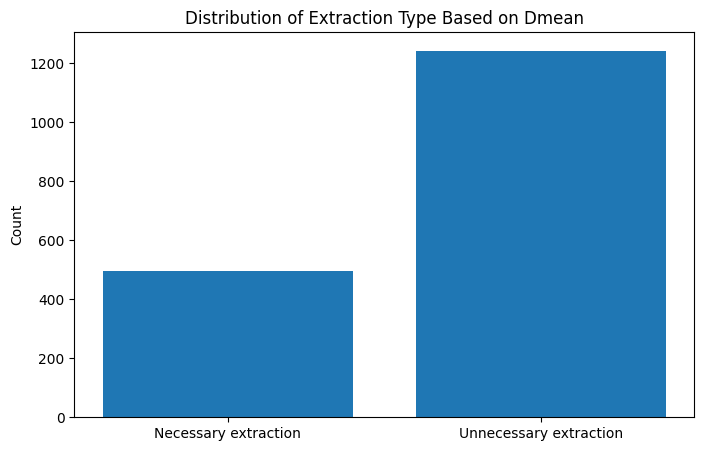

In [18]:
value_counts = {
    "Necessary extraction": (dmean_dff['ExtractionFlag'] == 1).sum().sum(),
    "Unnecessary extraction": (dmean_dff['ExtractionFlag'] == 0).sum().sum(),
}

plt.figure(figsize=(8, 5))
plt.bar(value_counts.keys(), value_counts.values())
plt.ylabel("Count")
plt.title("Distribution of Extraction Type Based on Dmean")
plt.show()


# DMax dataset

In [ ]:
columns_first = [f'DmaxGy{i}' for i in range(11, 19)] + [f'DmaxGy{i}' for i in range(21, 29)] + [f'DmaxGy{i}' for i in range(31, 39)] + [f'DmaxGy{i}' for i in range(41, 49)]

g1 = [f'DmaxGyCU{i}F' for i in range(1, 9)]   
g2 = [f'DmaxGyIU{i}F' for i in range(1, 9)]   
g3 = [f'DmaxGyIL{i}F' for i in range(1, 9)]   
g4 = [f'DmaxGyCL{i}F' for i in range(1, 9)]   

rename_dict = {}

for col in g1:
    i = int(col.replace("DmaxGyCU", "").replace("F", ""))
    rename_dict[col] = f"DmaxB{10 + i}"

for col in g2:
    i = int(col.replace("DmaxGyIU", "").replace("F", ""))
    rename_dict[col] = f"DmaxB{20 + i}"

for col in g3:
    i = int(col.replace("DmaxGyIL", "").replace("F", ""))
    rename_dict[col] = f"DmaxB{30 + i}"

for col in g4:
    i = int(col.replace("DmaxGyCL", "").replace("F", ""))
    rename_dict[col] = f"DmaxB{40 + i}"

columns_second = g1 + g2 + g3 + g4
selected_columns = ["PatientID"] + columns_first + columns_second

dmax_df = df[selected_columns].copy()
dmax_df.rename(columns=rename_dict, inplace=True)

dmax_df.head()

In [ ]:
melted_df2 = pd.wide_to_long(
    dmax_df,
    stubnames=["DmaxGy", "DmaxB"],  
    i="PatientID",                    
    j="ToothType",                    
    suffix=r"\d+",                    
    sep=""                            
).reset_index()

melted_df2.rename(columns={"DmaxGy": "DoseMax", "DmaxB": "ExtractionFlag"}, inplace=True)

print("NaN in DoseMax:", melted_df2["DoseMax"].isna().sum())
print("NaN in ExtractionFlag:", melted_df2["ExtractionFlag"].isna().sum())

melted_df2.dropna(subset=["ExtractionFlag"], inplace=True)

valid_tooth_types = (
    list(range(11, 19)) +
    list(range(21, 29)) +
    list(range(31, 39)) +
    list(range(41, 49))
)
melted_df2 = melted_df2[melted_df2["ToothType"].isin(valid_tooth_types)]
melted_df2 = melted_df2[["PatientID", "ToothType", "ExtractionFlag"]]
melted_df2.head()


In [ ]:
dmax_dff = melted_df2.copy()
dmax_dff = dmax_dff.merge(features, on="PatientID", how="left")
dmax_dff = dmax_dff[~((dmax_dff['StageItmIV'] == 99.0) | (dmax_dff['Stage'] == 99.0))]
print(dmax_dff.shape)
dmax_dff.head()

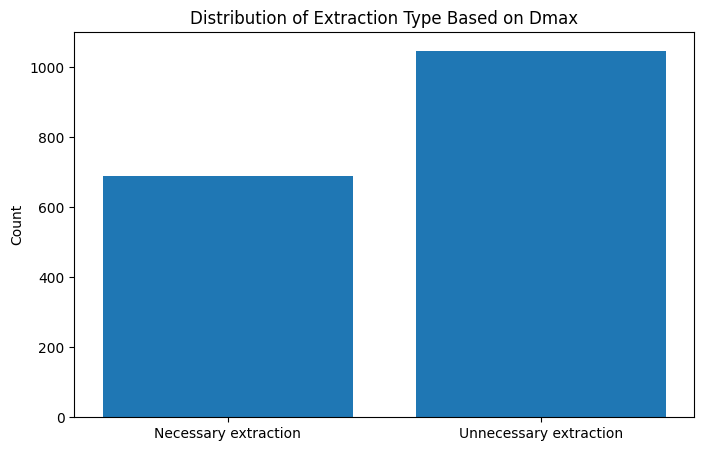

In [22]:
value_counts = {
    "Necessary extraction": (dmax_dff['ExtractionFlag'] == 1).sum().sum(),
    "Unnecessary extraction": (dmax_dff['ExtractionFlag'] == 0).sum().sum(),
}

plt.figure(figsize=(8, 5))
plt.bar(value_counts.keys(), value_counts.values())
plt.ylabel("Count")
plt.title("Distribution of Extraction Type Based on Dmax")
plt.show()
